# Customers Segmentation with Clustering Analysis

Fase ini berfokus pada tahap **Knowledge Discovery** melalui teknik unsupervised learning untuk mengidentifikasi kelompok-kelompok alami di dalam dataset Lending Club Loans. Dengan melakukan segmentasi, profil risiko dan perilaku finansial nasabah dapat dipahami secara lebih mendalam untuk mendukung pengambilan keputusan kredit.

## 1. Load Data
Tahap awal mencakup persiapan pustaka analisis data serta pemuatan dataset yang telah melalui proses preprocessing pada Fase 1. Dataset ini terdiri dari 21 fitur yang telah dibersihkan dan siap untuk dianalisis.


In [38]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch


# Memuat dataset hasil preprocessing
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Mining Project/Clustering/clean_accepted_loans.csv')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348100 entries, 0 to 1348099
Data columns (total 21 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   last_fico_range_low       1348100 non-null  float64
 1   sub_grade                 1348100 non-null  float64
 2   int_rate                  1348100 non-null  float64
 3   term                      1348100 non-null  int64  
 4   last_credit_pull_d_year   1348100 non-null  float64
 5   last_credit_pull_d_month  1348100 non-null  float64
 6   fico_range_high           1348100 non-null  float64
 7   dti_bin                   1346842 non-null  float64
 8   acc_open_past_24mths      1348100 non-null  float64
 9   installment               1348100 non-null  float64
 10  home_ownership_MORTGAGE   1348100 non-null  int64  
 11  num_tl_op_past_12m        1348100 non-null  float64
 12  bc_open_to_buy            1348100 non-null  float64
 13  avg_cur_bal               1

In [41]:
df.head()

,last_fico_range_low,sub_grade,int_rate,term,last_credit_pull_d_year,last_credit_pull_d_month,fico_range_high,dti_bin,acc_open_past_24mths,installment,...,num_tl_op_past_12m,bc_open_to_buy,avg_cur_bal,total_bc_limit,tot_hi_cred_lim,mort_acc,annual_inc_bin,home_ownership_RENT,loan_amnt_bin,loan_status_binary
0,-1.478621,0.355195,0.157047,36,0.947171,-0.651600,-0.664409,0.0,-0.213159,-1.203638,...,0.462185,-0.746076,0.742139,-1.085488,0.092814,-0.328345,1.0,0,0.0,0.0
1,0.257912,-0.109307,-0.262620,36,0.947171,-0.651600,0.591422,1.0,-0.213159,1.462740,...,-0.094374,2.470954,-0.204173,2.561235,1.037085,1.196774,2.0,0,3.0,0.0
2,0.322228,-0.418975,-0.516518,60,0.947171,-0.651600,-0.036493,1.0,0.425828,-0.019571,...,-1.207493,-0.614110,1.683965,-0.852979,0.373164,1.705146,2.0,0,2.0,0.0
3,0.322228,2.213205,1.932239,60,-0.140554,-0.651600,-0.036493,2.0,1.703801,-0.565467,...,1.018745,-0.417931,1.341177,0.009753,1.909032,2.213519,3.0,0,2.0,0.0
4,1.029704,0.200361,0.041639,36,-1.228280,-0.074003,-0.193472,1.0,-1.491133,-0.124658,...,-1.207493,-0.817044,-0.823055,-0.657182,-1.026349,-0.836718,1.0,1,2.0,0.0


In [39]:
# Menghapus baris dengan nilai kosong yang tersisa (NaN)
# Terdapat sejumlah kecil nilai kosong pada fitur binning
df_clean = df.dropna().reset_index(drop=True)

print(f"Total baris yang dianalisis: {len(df_clean)}")

Total baris yang dianalisis: 1346838


## 2. Standarisasi Fitur dan Pemisahan Variabel
Algoritma clustering berbasis *distance* seperti K-Means sangat sensitif terhadap skala data. Oleh karena itu, seluruh fitur numerik disetarakan bobotnya menggunakan StandardScaler. Fitur loan_status_binary dipisahkan dari proses clustering karena merupakan variabel target/hasil yang akan digunakan sebagai alat validasi profil di tahap akhir.

In [42]:
# Memisahkan fitur fitur dari variabel status pinjaman (target)
X_raw = df_clean.drop(columns=['loan_status_binary'])

# Melakukan scaling ulang agar fitur dengan rentang besar ('term') tidak mendominasi Euclidean distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Proses standarisasi fitur selesai.")

Proses standarisasi fitur selesai.


## 3. Penentuan Jumlah Klaster Optimal (K)
Untuk menentukan jumlah segmen nasabah yang paling representatif, digunakan dua metode evaluasi: Elbow Method (berdasarkan WCSS) dan Silhouette Score. Mengingat volume data yang besar, perhitungan Silhouette Score dilakukan menggunakan sampel acak sebanyak 20.000 data untuk efisiensi komputasi tanpa mengurangi validitas tren metrik.

In [43]:
wcss = []
silhouette_scores = []
K_range = range(2, 8)

# Sampling untuk perhitungan Silhouette Score
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], 20000, replace=False)
X_sample = X_scaled[sample_indices]

for k in K_range:
    # Eksekusi K-Means untuk Elbow Method
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    # Eksekusi K-Means pada sampel untuk Silhouette Score
    kmeans_sample = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans_sample.fit_predict(X_sample)
    sil_score = silhouette_score(X_sample, cluster_labels)
    silhouette_scores.append(sil_score)

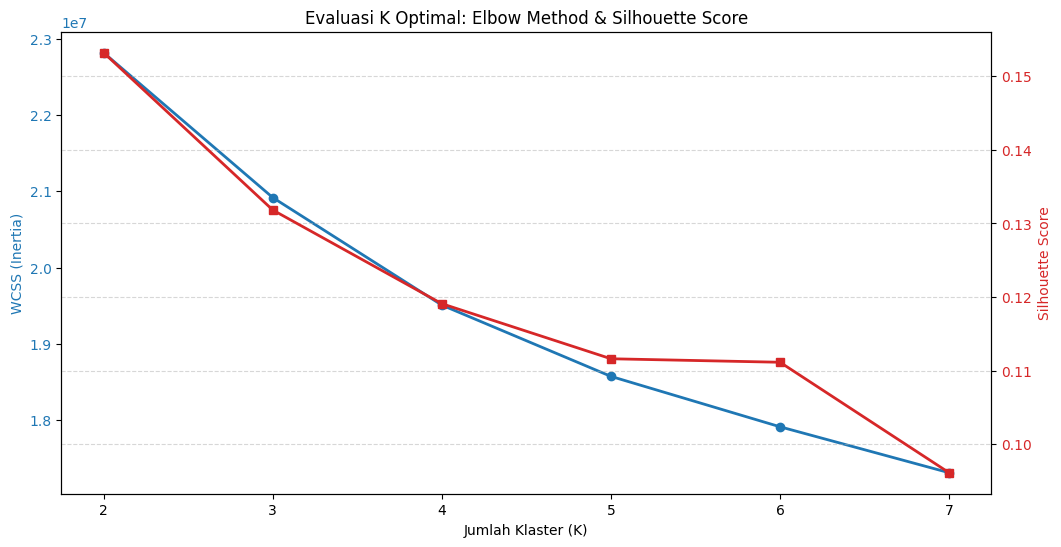

In [44]:
# Visualisasi perbandingan Elbow vs Silhouette
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:blue')
ax1.plot(K_range, wcss, marker='o', color='tab:blue', linewidth=2, label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_scores, marker='s', color='tab:red', linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Evaluasi K Optimal: Elbow Method & Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Analisis Hasil**: Berdasarkan grafik di atas, ditemukan bahwa titik "siku" (Elbow) mulai melandai pada K=3. Sejalan dengan itu, Silhouette Score menunjukkan nilai puncak tertinggi pada K=3. Hal ini mengindikasikan bahwa data secara alami terbagi menjadi 3 kelompok utama dengan kepadatan dan pemisahan yang optimal.

## 4. Analisis Struktur melalui Hierarchical Clustering
Metode Hierarchical Clustering digunakan untuk memvisualisasikan struktur kedekatan antar data dalam bentuk pohon hierarki (dendrogram). Visualisasi ini membantu memvalidasi apakah penggabungan klaster pada K=3 konsisten dengan struktur jarak data.

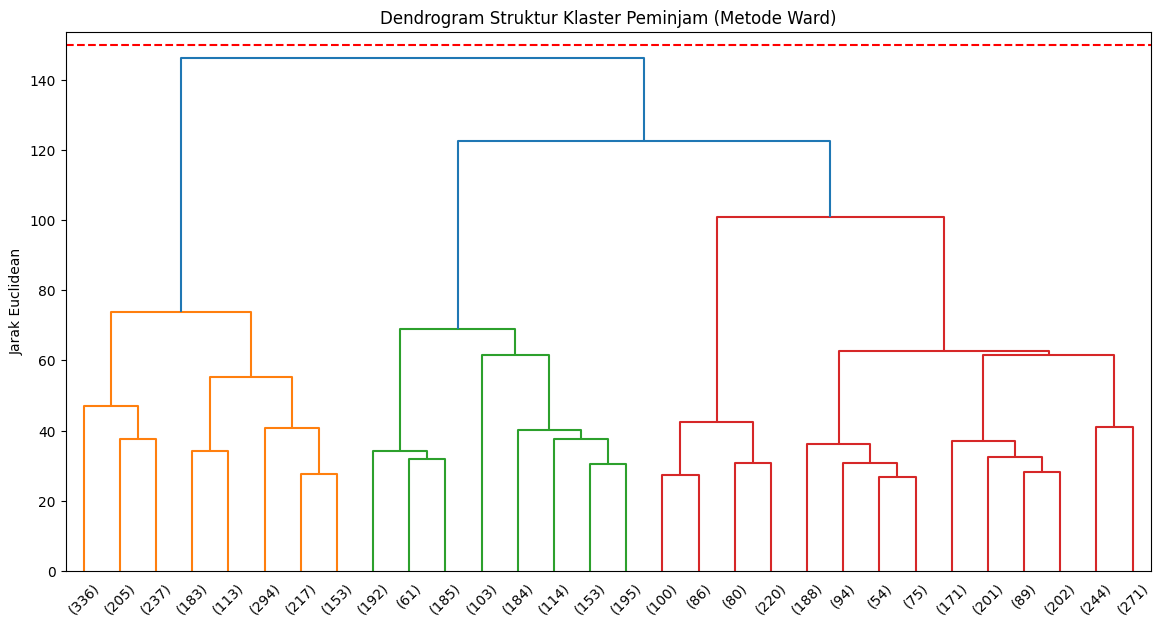

In [45]:
# Menggunakan sampel 5.000 data untuk visualisasi Dendrogram
sample_indices_h = np.random.choice(X_scaled.shape[0], 5000, replace=False)
X_sample_h = X_scaled[sample_indices_h]

plt.figure(figsize=(14, 7))
plt.title('Dendrogram Struktur Klaster Peminjam (Metode Ward)')
dendrogram = sch.dendrogram(sch.linkage(X_sample_h, method='ward'),
                            truncate_mode='lastp', p=30)
plt.axhline(y=150, color='r', linestyle='--') # Ambang batas pemotongan klaster
plt.ylabel('Jarak Euclidean')
plt.show()

**Analisis Hasil**:
Visualisasi dendrogram di atas memetakan proses penggabungan hierarkis dari 5.000 sampel data nasabah menggunakan algoritma Agglomerative Clustering dengan metode Ward. Sumbu vertikal (Jarak Euclidean) merepresentasikan tingkat ketidaksamaan (dissimilarity) antar titik data atau kelompok; semakin tinggi titik pertemuan (linkage), semakin besar perbedaan karakteristik finansial antar kelompok tersebut.

Berdasarkan grafik, ambang batas pemotongan (cut-off threshold) ditetapkan pada garis putus-putus merah di jarak Euclidean sebesar 150. Pada garis potong ini, dapat diamati tepat 3 cabang vertikal utama yang terpisah secara tegas tanpa adanya persilangan jarak dekat. Struktur visual ini memberikan dua temuan krusial:

1. Validasi Jumlah Klaster Optimal: Kemunculan 3 cabang utama yang solid memvalidasi dan mengonfirmasi hasil evaluasi Elbow Method dan Silhouette Score pada tahap sebelumnya. Hal ini memperkuat keputusan bahwa menetapkan nilai K=3 adalah pilihan paling natural dan optimal untuk segmentasi dataset ini.

2. Struktur Kedekatan Profil: Grafik menunjukkan pembelahan pertama yang sangat ekstrem pada jarak ~300, yang membagi nasabah menjadi dua populasi raksasa. Populasi sebelah kiri kemudian terbagi lagi menjadi dua klaster pada jarak ~165, sementara populasi sebelah kanan bertahan sebagai satu klaster tunggal hingga jarak yang lebih rendah. Struktur ini mengindikasikan adanya satu segmen nasabah (cabang kanan) yang profil risikonya sangat kontras dan fundamental berbeda dibandingkan dengan dua segmen lainnya.

## 5. Deteksi Outlier dengan DBSCAN
Berbeda dengan K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) mampu mengidentifikasi titik data yang berada di luar jangkauan kelompok utama (anomali). Tahap ini bertujuan untuk melihat seberapa besar proporsi nasabah dengan profil "tidak lazim" dalam dataset.

In [46]:
# Eksekusi DBSCAN pada sampel data
dbscan = DBSCAN(eps=3.5, min_samples=10)
db_labels = dbscan.fit_predict(X_sample_h)

n_noise = list(db_labels).count(-1)
print(f"Hasil Deteksi Outlier (DBSCAN):")
print(f"- Jumlah Anomali Terdeteksi: {n_noise} dari 5.000 sampel")
print(f"- Persentase Outlier: {(n_noise/5000)*100:.2f}%")

Hasil Deteksi Outlier (DBSCAN):
- Jumlah Anomali Terdeteksi: 165 dari 5.000 sampel
- Persentase Outlier: 3.30%


**Analisis Hasil**:

Algoritma DBSCAN dijalankan secara khusus untuk mengidentifikasi keberadaan nasabah dengan profil outlier struktural, yakni entitas data yang tidak memiliki kepadatan seragam dengan kelompok klaster mana pun dan berpotensi merepresentasikan perilaku anomali.

Berdasarkan sampel 5.000 data nasabah, algoritma berhasil mendeteksi 165 titik data (3,30%) yang diklasifikasikan sebagai noise (label -1). Dalam konteks manajemen risiko perbankan, persentase ini adalah temuan yang sangat wajar dan berharga.

Keberadaan 3,30% populasi di luar klaster utama mengindikasikan adanya kelompok kecil peminjam dengan kombinasi profil finansial yang sangat ekstrem atau tidak lazim (misalnya: individu dengan pendapatan sangat tinggi namun skor FICO sangat rendah, atau sebaliknya).

Fakta bahwa 96,70% data berhasil dikelompokkan ke dalam klaster utama membuktikan bahwa dataset memiliki struktur mayoritas yang solid, dan keputusan segmentasi pada K=3 menggunakan algoritma berbasis titik pusat (seperti K-Means) sudah sangat tepat dan tidak akan terlalu terdistorsi oleh titik ekstrem.

Temuan anomali awal ini akan menjadi landasan penting untuk Fase 4 (Anomaly Detection) pada pipeline KDD. Di fase tersebut, metode seperti Isolation Forest akan dikerahkan lebih dalam untuk membedah apakah 3,30% anomali ini merupakan murni error data, kasus spesial yang sah, atau sinyal risiko struktural yang membutuhkan intervensi bisnis khusus.

## 6. Implementasi Final K-Means dan Pembentukan Profil Klaster
Mengacu pada hasil evaluasi metrik sebelumnya, algoritma K-Means dijalankan pada seluruh populasi data (1,3 juta baris) dengan nilai K=3. Label klaster kemudian digabungkan kembali ke dataset asli untuk dilakukan analisis karakteristik tiap kelompok.

In [47]:
# Eksekusi K-Means Final pada 100% data
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_clean['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

# Agregasi statistik untuk melihat karakteristik tiap klaster
# Menggunakan median untuk fitur-fitur penting
cluster_summary = df_clean.groupby('Cluster_Label').agg({
    'int_rate': 'mean',
    'fico_range_high': 'mean',
    'loan_amnt_bin': 'median',
    'annual_inc_bin': 'median',
    'dti_bin': 'mean',
    'loan_status_binary': 'mean' # Tingkat gagal bayar/lunas
}).round(4)

print("Profil Karakteristik Tiap Klaster:")
display(cluster_summary)

Profil Karakteristik Tiap Klaster:


,int_rate,fico_range_high,loan_amnt_bin,annual_inc_bin,dti_bin,loan_status_binary
Cluster_Label,,,,,,
0,1.0732,-0.3989,2.0,2.0,1.5810,0.3782
1,-0.1693,-0.1779,1.0,1.0,1.2595,0.1769
2,-0.6592,0.6066,2.0,2.0,1.1771,0.0824


## 7. Analisis Karakteristik dan Profiling Klaster

Setelah label klaster digabungkan ke dalam dataset utama, dilakukan analisis statistik deskriptif menggunakan nilai rata-rata (*mean*) untuk fitur kontinu yang telah di-*scaling* (Z-score) dan variabel target. Analisis ini bertujuan untuk mendefinisikan persona atau profil nasabah pada masing-masing kelompok berdasarkan perilaku finansial dan tingkat risiko mereka.

| Cluster | int_rate | fico_high | loan_amnt | annual_inc | dti_bin | loan_status (Risk) |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **0** | 1.0732 | -0.3989 | 2.0 | 2.0 | 1.5810 | 0.3782 |
| **1** | -0.1693 | -0.1779 | 1.0 | 1.0 | 1.2595 | 0.1769 |
| **2** | -0.6592 | 0.6066 | 2.0 | 2.0 | 1.1771 | 0.0824 |

#### Interpretasi Profil Nasabah:

**1. Klaster 0: *High-Risk & High-Debt Borrowers***
* **Profil Keuangan:** Nasabah dalam kelompok ini memiliki beban utang (*Debt-to-Income*) tertinggi (1.5810) dan skor kredit FICO terendah (-0.3989) di antara seluruh kelompok. Meskipun mereka memiliki pendapatan tinggi dan mengambil pinjaman dalam jumlah besar, manajemen utang mereka terlihat kurang stabil.
* **Tingkat Risiko:** Kelompok ini dikenakan suku bunga tertinggi (1.0732) sebagai kompensasi risiko. Data menunjukkan tingkat gagal bayar tertinggi mencapai **37,82%**. Ini merupakan segmen yang paling diwaspadai oleh institusi perbankan.

**2. Klaster 1: *Moderate-Risk & Small-Scale Borrowers***
* **Profil Keuangan:** Segmen ini mewakili nasabah dengan skala ekonomi menengah ke bawah, baik dari sisi pendapatan maupun jumlah pinjaman yang diajukan. Skor kredit dan suku bunga mereka berada sedikit di bawah rata-rata populasi secara umum.
* **Tingkat Risiko:** Dengan rasio utang yang moderat (1.2595), tingkat risiko gagal bayar pada kelompok ini berada di level menengah, yaitu sebesar **17,69%**. Kelompok ini mencerminkan profil peminjam ritel standar.

**3. Klaster 2: *Prime & Low-Risk Borrowers* (Nasabah Prioritas)**
* **Profil Keuangan:** Kelompok ini adalah segmen nasabah paling sehat secara finansial. Mereka memiliki skor kredit FICO tertinggi (0.6066) dan rasio utang terendah (1.1771). Karakteristik utama mereka adalah kemampuan mengambil pinjaman besar dengan tetap menjaga profil kredit yang sangat baik.
* **Tingkat Risiko:** Bank memberikan kepercayaan penuh kepada segmen ini dengan memberikan suku bunga terendah (-0.6592). Terbukti, tingkat risiko gagal bayar pada kelompok ini adalah yang paling kecil, yaitu hanya sebesar **8,24%**.

#### Kesimpulan Segmentasi:
Segmentasi ini menunjukkan bahwa variabel *Debt-to-Income* (DTI) dan skor FICO menjadi pembeda utama dalam menentukan profil risiko nasabah. Nasabah dengan pendapatan tinggi tidak selalu berarti memiliki risiko rendah (seperti terlihat pada perbandingan Klaster 0 dan 2), melainkan kedisiplinan dalam mengelola rasio utanglah yang menjadi faktor penentu utama kualitas kredit seorang nasabah.